In [2]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from Data_Preprocessing.paths import PREPROCESSED_PATHS

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 6)
sns.set_style("whitegrid")

In [3]:
# Load the processed dataset
DATA_PATH = PREPROCESSED_PATHS["processed_full_features"]
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)

# Define Target
TARGET = "target_volatility"

# We must drop future-leaking columns (like the price itself if we are predicting volatility)
# and highly collinear features identified in the VIF analysis.
cols_to_drop = [
    'log_return', 'log_price', 'volatility_4p', 'volatility_8p', 'volatility_12p',
    'log_return_lag1', 'log_return_lag2', 'log_return_lag4',
    'log_price_lag1', 'log_price_lag2', 'log_price_lag4',
    'Exchange_Rate', 'Exchange_Rate_lag1', 'Exchange_Rate_lag2', 'Exchange_Rate_lag4' # Dropped due to extreme VIF
]

# Keep only columns that actually exist in the dataframe
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

# Define Feature Matrix (X) and Target Vector (y)
X = df.drop(columns=cols_to_drop + [TARGET])
y = df[TARGET]

# Drop any remaining NaNs caused by lagging/windowing
valid_idx = X.dropna().index.intersection(y.dropna().index)
X = X.loc[valid_idx]
y = y.loc[valid_idx]

print(f"Final Modeling Dataset Shape: {X.shape}")

Final Modeling Dataset Shape: (367, 63)


Training Dates: 2017-05-28 to 2024-05-26 (293 rows)
Testing Dates: 2024-06-02 to 2025-10-26 (74 rows)


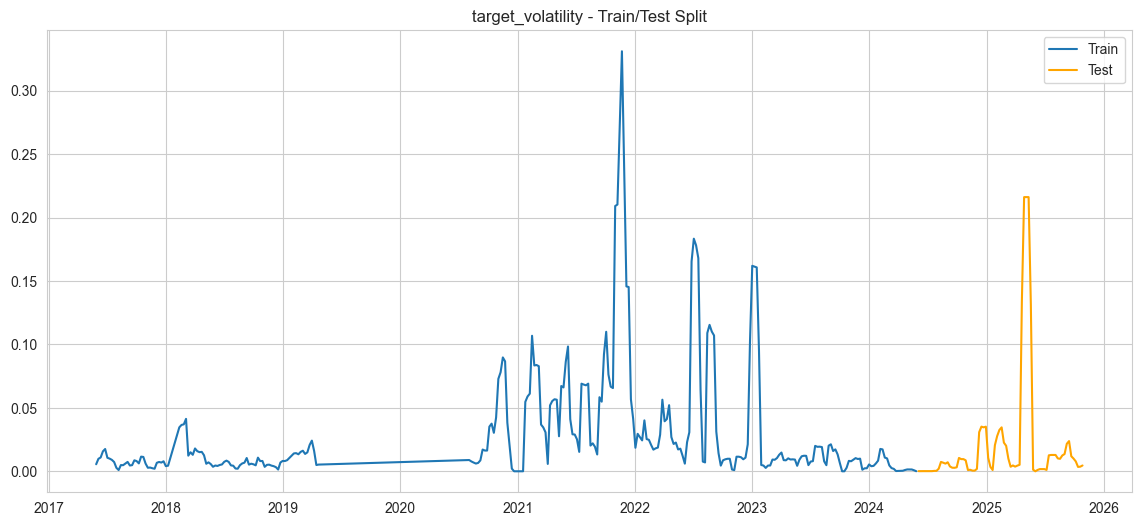

In [4]:
# In Time Series, we CANNOT randomize the split. We must split chronologically.
# Let's use 80% of the data for training and the last 20% for testing.
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training Dates: {X_train.index.min().date()} to {X_train.index.max().date()} ({len(X_train)} rows)")
print(f"Testing Dates: {X_test.index.min().date()} to {X_test.index.max().date()} ({len(X_test)} rows)")

# Visualize the split
plt.plot(y_train.index, y_train, label='Train')
plt.plot(y_test.index, y_test, label='Test', color='orange')
plt.title(f"{TARGET} - Train/Test Split")
plt.legend()
plt.show()

In [8]:
print("Training SARIMAX Baseline Model...")

# Select a few top features to act as exogenous variables (exog)
top_exog_features = ['Exchange_Rate_30d_PctChange', 'season_2021Yala', 'Temp_Min_C', 'Supply_YoY_Change_%']
top_exog_features = [c for c in top_exog_features if c in X_train.columns]

# Extract exogenous features and force float types to prevent "dtype object" errors
exog_train_num = X_train[top_exog_features].astype(float)
exog_test_num = X_test[top_exog_features].astype(float)

y_train_num = y_train.astype(float)
y_test_num = y_test.astype(float)

# =========================================================
# THE FIX: Reset index to integer steps to bypass Date Errors
# =========================================================
y_train_reset = y_train_num.reset_index(drop=True)
exog_train_reset = exog_train_num.reset_index(drop=True)
exog_test_reset = exog_test_num.reset_index(drop=True)

# Fit SARIMAX(1, 0, 1) using the reset integer index
sarimax_model = SARIMAX(y_train_reset, exog=exog_train_reset, order=(1, 0, 1))
sarimax_results = sarimax_model.fit(disp=False)

# Predict using mathematical integer steps
start_step = len(y_train_reset)
end_step = len(y_train_reset) + len(y_test_num) - 1
sarimax_preds = sarimax_results.predict(start=start_step, end=end_step, exog=exog_test_reset)

# Re-attach the actual dates back onto the predictions for plotting
sarimax_preds.index = y_test_num.index

# =========================================================
# Evaluate Performance
# =========================================================
mae_sarimax = mean_absolute_error(y_test_num, sarimax_preds)
rmse_sarimax = np.sqrt(mean_squared_error(y_test_num, sarimax_preds))

print(f"SARIMAX MAE:  {mae_sarimax:.5f}")
print(f"SARIMAX RMSE: {rmse_sarimax:.5f}")

Training SARIMAX Baseline Model...
SARIMAX MAE:  0.02712
SARIMAX RMSE: 0.04583


In [10]:
print("Training XGBoost Regressor...")

# Filter out any remaining text/object columns (like the raw 'Season' column)
numeric_cols = X_train.select_dtypes(include=['number', 'bool']).columns
X_train_num = X_train[numeric_cols].astype(float)
X_test_num = X_test[numeric_cols].astype(float)

# XGBoost handles the full numeric feature set seamlessly
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Fit the model
xgb_model.fit(
    X_train_num, y_train_num,
    eval_set=[(X_train_num, y_train_num), (X_test_num, y_test_num)],
    verbose=False
)

# Predict
xgb_preds = xgb_model.predict(X_test_num)
xgb_preds = pd.Series(xgb_preds, index=y_test.index)

# Evaluate
mae_xgb = mean_absolute_error(y_test_num, xgb_preds)
rmse_xgb = np.sqrt(mean_squared_error(y_test_num, xgb_preds))

print(f"XGBoost MAE:  {mae_xgb:.5f}")
print(f"XGBoost RMSE: {rmse_xgb:.5f}")

Training XGBoost Regressor...
XGBoost MAE:  0.03079
XGBoost RMSE: 0.04675


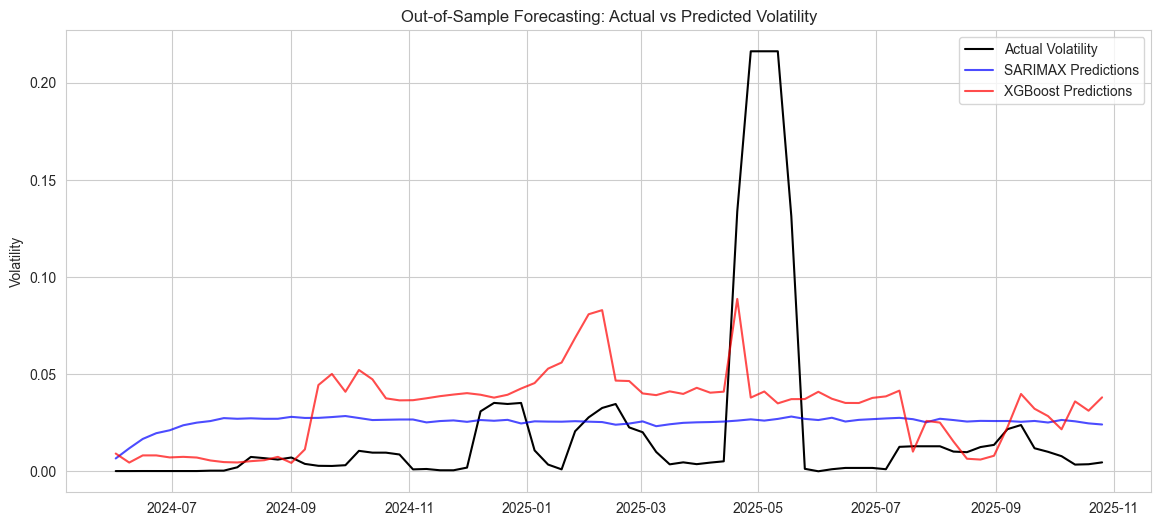

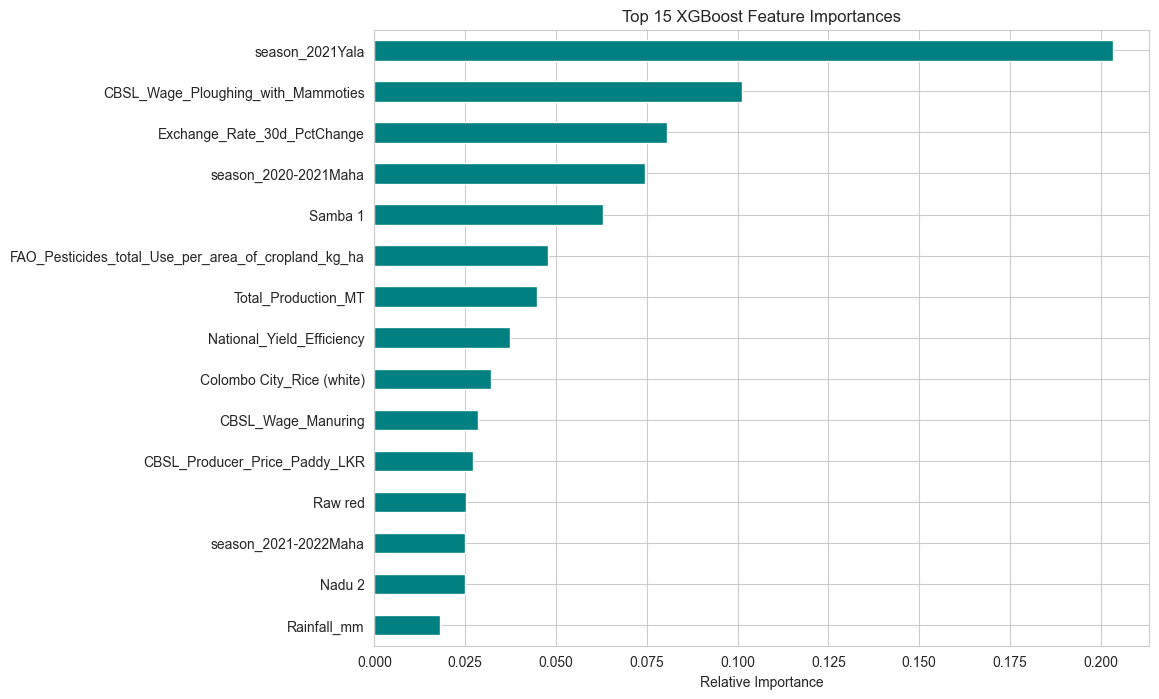

In [11]:
# Plot Actuals vs Predictions
plt.plot(y_test.index, y_test, label='Actual Volatility', color='black', linewidth=1.5)
plt.plot(y_test.index, sarimax_preds, label='SARIMAX Predictions', color='blue', alpha=0.7)
plt.plot(y_test.index, xgb_preds, label='XGBoost Predictions', color='red', alpha=0.7)

plt.title("Out-of-Sample Forecasting: Actual vs Predicted Volatility")
plt.ylabel("Volatility")
plt.legend()
plt.show()

# Feature Importance from XGBoost using the filtered numeric columns
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train_num.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
xgb_importance.tail(15).plot(kind='barh', color='teal')
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Relative Importance")
plt.show()

In [12]:
print("Training Log-Transformed XGBoost Model...")

# Small constant to prevent log(0)
EPSILON = 1e-4

# Log-transform targets
y_train_log = np.log(y_train_num + EPSILON)
y_test_log = np.log(y_test_num + EPSILON)

# Train XGBoost on log-scale
xgb_log_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_log_model.fit(
    X_train_num, y_train_log,
    eval_set=[(X_train_num, y_train_log), (X_test_num, y_test_log)],
    verbose=False
)

# Predict and invert transformation back to original scale
xgb_log_preds_log = xgb_log_model.predict(X_test_num)
xgb_log_preds = np.exp(xgb_log_preds_log) - EPSILON
xgb_log_preds = np.clip(xgb_log_preds, 0, None)  # Floor at 0
xgb_log_preds = pd.Series(xgb_log_preds, index=y_test.index)

# Evaluate
mae_xgb_log = mean_absolute_error(y_test_num, xgb_log_preds)
rmse_xgb_log = np.sqrt(mean_squared_error(y_test_num, xgb_log_preds))

print(f"Log-XGBoost MAE:  {mae_xgb_log:.5f}")
print(f"Log-XGBoost RMSE: {rmse_xgb_log:.5f}")

Training Log-Transformed XGBoost Model...
Log-XGBoost MAE:  0.01889
Log-XGBoost RMSE: 0.04887


In [14]:
from arch import arch_model

# =========================================================
# 2. GARCH / EGARCH on Log Returns
# =========================================================
print("Fitting GARCH(1,1) Model on Log Returns (Expanding Window)...")

# Extract log returns matching train and test split
returns = df['log_return'].dropna()
r_train = returns.loc[returns.index.isin(y_train.index)] * 100 # Rescale by 100 for numerical stability
r_test = returns.loc[returns.index.isin(y_test.index)] * 100

garch_forecasts = []

# Perform an expanding window forecast
for t in range(len(r_test)):
    # 1. Expand the history with newly revealed test data step-by-step
    history = pd.concat([r_train, r_test.iloc[:t]])
    
    # 2. INSTANTIATE a new model on the updated history
    temp_garch = arch_model(history, vol='Garch', p=1, q=1, dist='Normal', rescale=False)
    
    # 3. Fit the model 
    res = temp_garch.fit(disp='off')
    
    # 4. Forecast 1 step ahead (reindex=False prevents warnings in newer arch versions)
    f = res.forecast(horizon=1, reindex=False)
    
    # Extract the forecasted variance and convert back to volatility scale
    cond_var = f.variance.iloc[-1, 0]
    garch_forecasts.append(np.sqrt(cond_var) / 100)

# Convert to a pandas Series matched to the test timeline
garch_preds = pd.Series(garch_forecasts, index=y_test_num.index)

# Evaluate
mae_garch = mean_absolute_error(y_test_num, garch_preds)
rmse_garch = np.sqrt(mean_squared_error(y_test_num, garch_preds))

print(f"GARCH(1,1) MAE:  {mae_garch:.5f}")
print(f"GARCH(1,1) RMSE: {rmse_garch:.5f}")

Fitting GARCH(1,1) Model on Log Returns (Expanding Window)...
GARCH(1,1) MAE:  0.02884
GARCH(1,1) RMSE: 0.04322


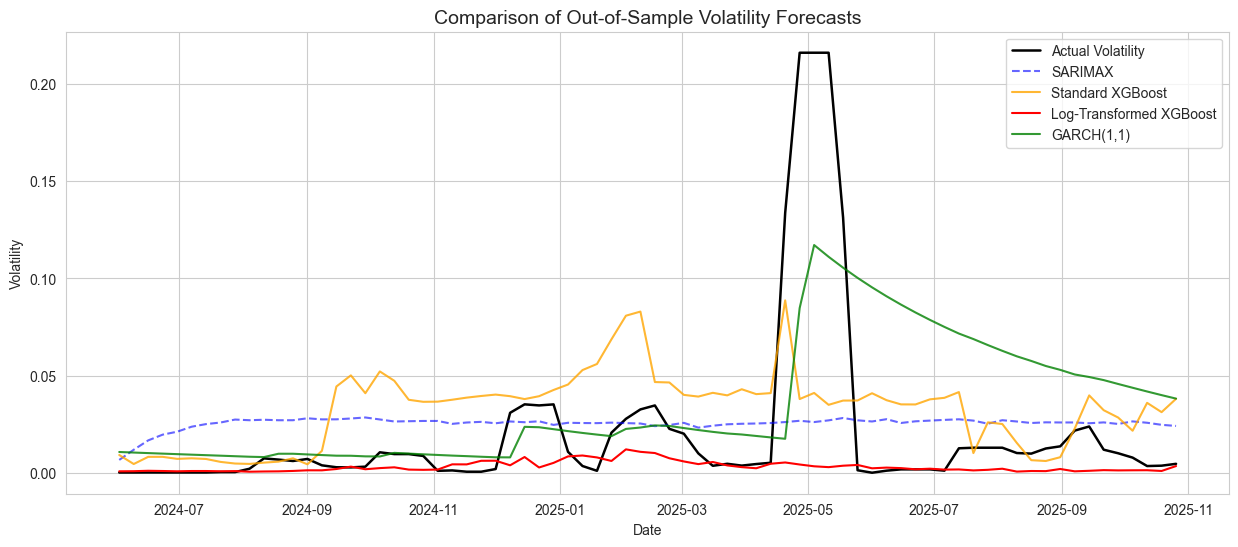

In [15]:
# Plot All Forecasting Trajectories
plt.figure(figsize=(15, 6))
plt.plot(y_test.index, y_test, label='Actual Volatility', color='black', linewidth=1.8)
plt.plot(y_test.index, sarimax_preds, label='SARIMAX', color='blue', linestyle='--', alpha=0.6)
plt.plot(y_test.index, xgb_preds, label='Standard XGBoost', color='orange', alpha=0.8)
plt.plot(y_test.index, xgb_log_preds, label='Log-Transformed XGBoost', color='red', linewidth=1.5)
plt.plot(y_test.index, garch_preds, label='GARCH(1,1)', color='green', alpha=0.8)

plt.title("Comparison of Out-of-Sample Volatility Forecasts", fontsize=14)
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()